# Case 2 – Economia: Previsão de Inadimplência de Microempreendedores
Contexto: Uma fintech de microcrédito quer prever a **probabilidade de inadimplência de pequenos empreendedores**, com base no histórico de pagamentos e dados socioeconômicos.

Dados Sintéticos (amostra):

* Cliente_ID

* Idade (18–65 anos)

* Gênero

* Setor do negócio (Comércio, Serviços, Agricultura)

* Faturamento médio mensal ( 500 a 15.000 Reais)

* Valor do empréstimo solicitado (1.000 a 20.000 Reais)
* Score interno (0 a 1000)


* Atrasos anteriores (número de parcelas atrasadas nos últimos 12 meses)


* Inadimplente (Sim/Não – variável alvo)



**Objetivo de Análise:**
Desenvolver um modelo preditivo para classificar clientes entre alto risco e baixo risco de inadimplência, otimizando a concessão de crédito.


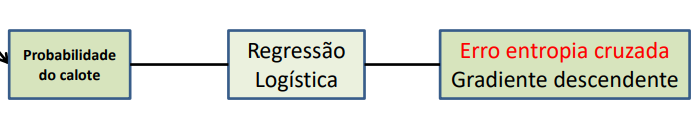

A Regressão Logística utiliza probabilidade porque o problema que ela resolve (classificação) **não é sobre "quanto", mas sobre "qual a chance".**

Em economia, o cliente ou paga (0) ou não paga (1). Não existe "meio inadimplente". A probabilidade permite medir a incerteza entre esses dois estados.


Ela usa probabilidade porque transforma um problema de regressão matemática em um estimador de incerteza, permitindo que o gestor escolha o nível de risco que está disposto a aceitar.

# Planejamento da predição

O modelo é organizado em camadas complementares:



1. Camada do Cliente: utiliza **aprendizagem de máquina** para estimar a probabilidade de inadimplência. (Regressão Logística)
2. Camada Temporal: aplica o modelo **ARIMA** para prever a tendência futura da inadimplência da carteira.

O scikit-learn implementa internamente toda a matemática da regressão logística, incluindo:

Função logística (sigmoide)

Função de verossimilhança

Maximização da log-verossimilhança

Otimização numérica (ex.: Gradient Descent, LBFGS)

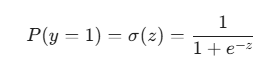

 O número Euler ($e \approx 2,718$) elevado a $-z$ é o que garante que o resultado nunca saia do intervalo $[0, 1]$.

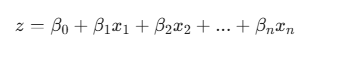

O Modelo calcula uma combinação linear das variáveis resultando em um valor z

$\beta_0$: É o intercepto (o risco base).

$\beta_1, \beta_2$: São os coeficientes (no seu caso, o peso do Score ou dos Atrasos).


$x_1, x_2$: São as variáveis de entrada.

/tmp/ipython-input-2089172966.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  meses = pd.date_range(start='2023-01-01', periods=36, freq='M')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


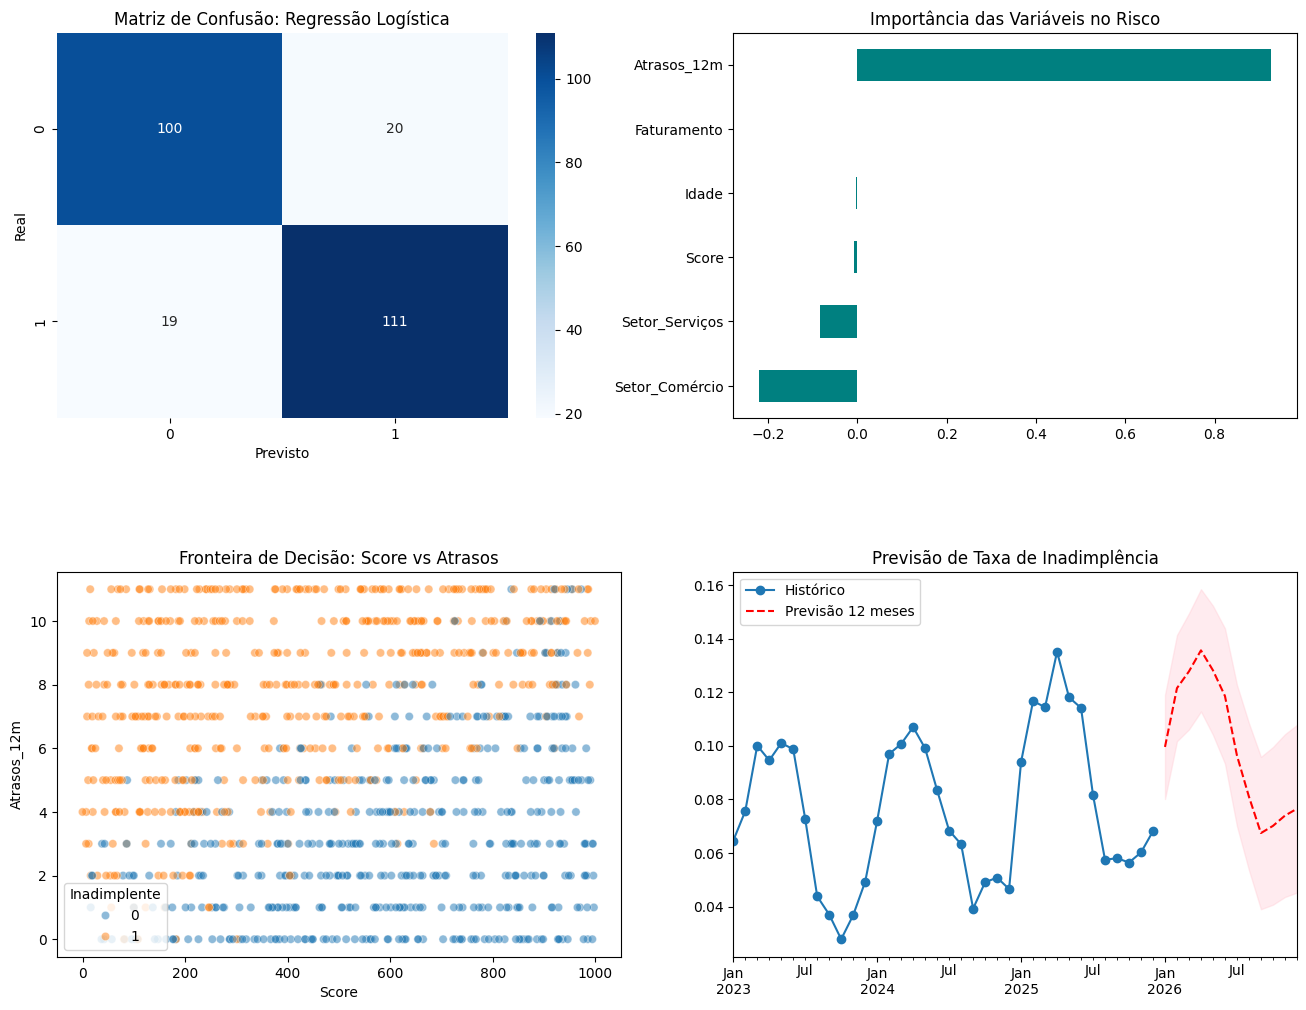

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       120
           1       0.85      0.85      0.85       130

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Geração de dados (Perfil dos Empreendedores)
np.random.seed(42)
n_samples = 1000

data = {
    'Idade': np.random.randint(18, 65, n_samples),
    'Faturamento': np.random.uniform(500, 15000, n_samples),
    'Score': np.random.randint(0, 1000, n_samples),
    'Atrasos_12m': np.random.randint(0, 12, n_samples),
    'Setor': np.random.choice(['Comércio', 'Serviços', 'Agricultura'], n_samples)
}
df = pd.DataFrame(data)

# Lógica para Inadimplência (Variável Alvo)
# Inadimplência influenciada por Atrasos altos e Score baixo
logit_sim = (df['Atrasos_12m'] * 0.5) - (df['Score'] * 0.004) + np.random.normal(0, 1, n_samples)
df['Inadimplente'] = (logit_sim > 0.5).astype(int)

# Regressão Logística
# Transformando 'Setor' em variáveis numéricas (Dummy)
df_ml = pd.get_dummies(df, columns=['Setor'], drop_first=True)

X = df_ml.drop('Inadimplente', axis=1)
y = df_ml['Inadimplente']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

# ANÁLISE TEMPORAL (SARIMA) ---
# Simulando 36 meses de taxa de inadimplência com sazonalidade anual
meses = pd.date_range(start='2023-01-01', periods=36, freq='M')
tendencia = np.linspace(0.06, 0.10, 36)
sazonalidade = 0.04 * np.sin(2 * np.pi * np.arange(36) / 12)
taxa_serie = pd.Series(tendencia + sazonalidade + np.random.normal(0, 0.01, 36), index=meses)

# Ajuste do SARIMA (p,d,q) x (P,D,Q,s)
model_sarima = SARIMAX(taxa_serie, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = model_sarima.fit(disp=False)
forecast = sarima_fit.get_forecast(steps=12)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# Matriz de Confusão (ML)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Matriz de Confusão: Regressão Logística')
axes[0, 0].set_xlabel('Previsto')
axes[0, 0].set_ylabel('Real')

# Importância das Variáveis (Coeficientes)
coefs = pd.Series(model_lr.coef_[0], index=X.columns).sort_values()
coefs.plot(kind='barh', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Importância das Variáveis no Risco')

# Dispersão de Risco
sns.scatterplot(data=df, x='Score', y='Atrasos_12m', hue='Inadimplente', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Fronteira de Decisão: Score vs Atrasos')

# SARIMA
taxa_serie.plot(ax=axes[1, 1], label='Histórico', marker='o')
forecast.predicted_mean.plot(ax=axes[1, 1], label='Previsão 12 meses', color='red', ls='--')
conf_int = forecast.conf_int()
axes[1, 1].fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
axes[1, 1].set_title('Previsão de Taxa de Inadimplência')
axes[1, 1].legend()

plt.show()

# Resumo métrico
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))

# Análise dos Resultados

1) Matriz de Confusão:

* Acertos (Diagonal Principal): Foram identificados corretamente 100 bons pagadores e 111 inadimplentes.

* Falsos Negativos (19): Estes são os clientes "perigosos". O modelo disse que eram bons, mas eles falharam. Em crédito, esse é o erro mais caro.

* Falsos Positivos (20): Clientes que pagariam, mas foram recusados. Isso representa custo de oportunidade e perda de mercado para a concorrência.


2) Variável


* Atrasos_12m: É o maior preditor de risco. Cada atraso anterior aumenta drasticamente a chance de novo calote.


3) Fronteira de Decisão

* Há uma separação clara: Laranja (Inadimplente) concentra-se no topo (muitos atrasos) e à esquerda (baixo score).
* A "zona de batalha" está entre os Scores 400 e 600 com 4 a 6 atrasos. É aqui que a fintech deve aplicar regras humanas ou pedir garantias extras.


4) SARIMA

* **Sazonalidade**: O histórico mostra picos recorrentes no início de cada ano.
* Alerta: A previsão (linha vermelha) indica uma subida acentuada na inadimplência para o início de 2026.

**Recomendação é que a entre janeiro e abril de 2026, a fintech deve ser mais rigorosa na concessão, pois o cenário macroeconômico simulado indica uma deterioração da carteira nesse período.**


# Interpretação dos coeficientes da Regressão Logística

É a "Chance" (Odds). Se a chance de inadimplência é 0,8, a chance de pagamento é 0,2.

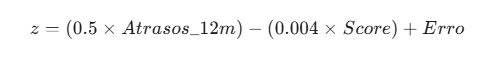

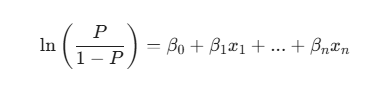

O modelo calcula uma combinação linear das variáveis (como Score e Atrasos), resultando em um valor $z$. Esse valor é passado pela função sigmoide, que mapeia o resultado em uma probabilidade entre 0 e 1. Se essa probabilidade for maior que um limite definido (geralmente 0,5), é classificado o microempreendedor como inadimplente.